In [31]:
pip install graphviz

Note: you may need to restart the kernel to use updated packages.


In [32]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset("titanic")
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [33]:
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
target = 'survived'


In [34]:
df = df.dropna(subset=['survived'])
df["age"] = df["age"].fillna(df["age"].median())
df = pd.get_dummies(df, columns=["sex", "pclass", "embarked"], drop_first=False)


In [35]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["survived", "class", "adult_male", "deck", "who", "alive", "embark_town", "alone"])
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [36]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=5, random_state=42)

In [37]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Feature columns:", list(X.columns))

Accuracy: 0.7988826815642458
Feature columns: ['age', 'sibsp', 'parch', 'fare', 'sex_female', 'sex_male', 'pclass_1', 'pclass_2', 'pclass_3', 'embarked_C', 'embarked_Q', 'embarked_S']


In [38]:
from sklearn.tree import export_graphviz
import graphviz

dot = export_graphviz(
    model,
    out_file=None,
    feature_names=X.columns,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot)
graph.render("titanic_tree", format="png")

'titanic_tree.png'

### Titanic — LIME Explanations


In [39]:
!pip install lime


In [40]:
import lime
import lime.lime_tabular

dummy_cols = ['sex_female', 'sex_male', 'pclass_1', 'pclass_2', 'pclass_3',
              'embarked_C', 'embarked_Q', 'embarked_S']
cat_feature_idx = [i for i, c in enumerate(X_train.columns) if c in dummy_cols]

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['Not Survived', 'Survived'],
    categorical_features=cat_feature_idx,
    mode='classification',
    random_state=42
)


In [41]:
test_labels = y_test.reset_index(drop=True)
X_test_arr = X_test.values
feature_names = X_train.columns.tolist()
sex_male_idx = feature_names.index('sex_male')

# female survivor
survivor_idx = next(
    i for i in test_labels[test_labels == 1].index
    if X_test_arr[i, sex_male_idx] == 0
)
# male non-survivor
non_survivor_idx = next(
    i for i in test_labels[test_labels == 0].index
    if X_test_arr[i, sex_male_idx] == 1
)

print(f"Survivor instance (test index {survivor_idx}) — female:")
print(dict(zip(feature_names, X_test_arr[survivor_idx])))
print(f"\nNon-survivor instance (test index {non_survivor_idx}) — male:")
print(dict(zip(feature_names, X_test_arr[non_survivor_idx])))


Survivor instance (test index 3) — female:
{'age': 6.0, 'sibsp': 0.0, 'parch': 1.0, 'fare': 33.0, 'sex_female': 1.0, 'sex_male': 0.0, 'pclass_1': 0.0, 'pclass_2': 1.0, 'pclass_3': 0.0, 'embarked_C': 0.0, 'embarked_Q': 0.0, 'embarked_S': 1.0}

Non-survivor instance (test index 1) — male:
{'age': 31.0, 'sibsp': 0.0, 'parch': 0.0, 'fare': 10.5, 'sex_female': 0.0, 'sex_male': 1.0, 'pclass_1': 0.0, 'pclass_2': 1.0, 'pclass_3': 0.0, 'embarked_C': 0.0, 'embarked_Q': 0.0, 'embarked_S': 1.0}


/Users/henrysalgado/opt/anaconda3/envs/data_science_env/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


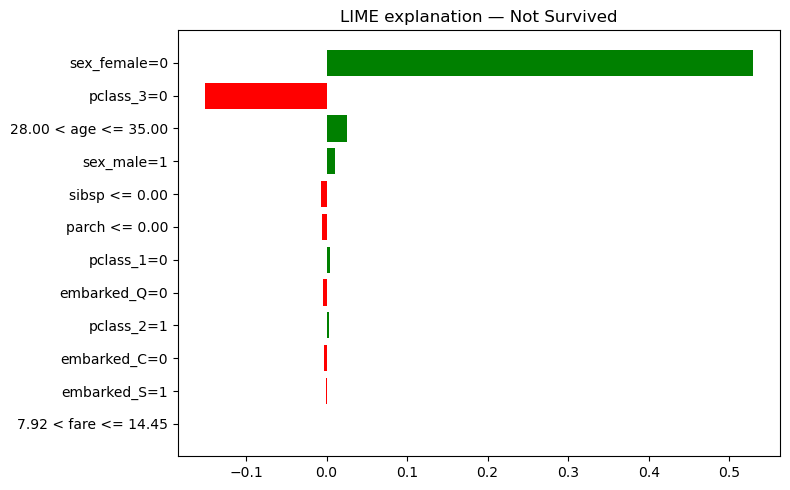

In [42]:
import matplotlib.pyplot as plt

exp_non = lime_explainer.explain_instance(
    X_test_arr[non_survivor_idx],
    model.predict_proba,
    num_features=len(X_train.columns),
    labels=(0, 1)
)

fig = exp_non.as_pyplot_figure(label=0)
fig.set_size_inches(8, 5)
plt.title("LIME explanation — Not Survived")
plt.tight_layout()
plt.savefig("lime_not_survived.png", dpi=150)
plt.show()


/Users/henrysalgado/opt/anaconda3/envs/data_science_env/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


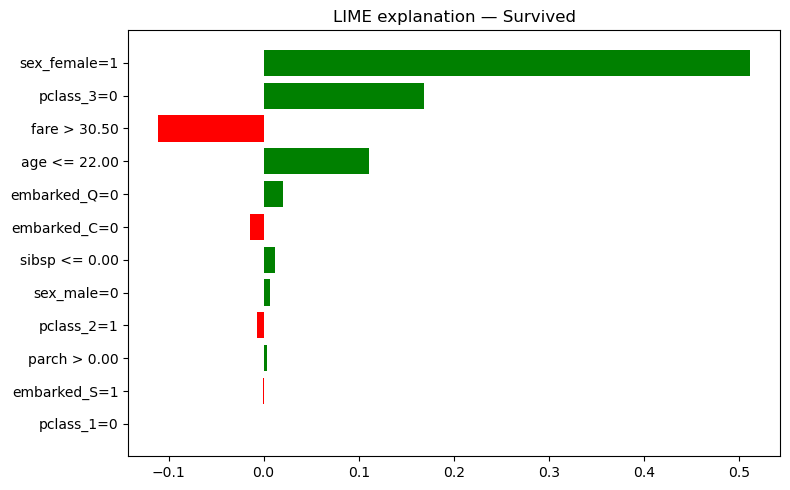

In [43]:
exp_sur = lime_explainer.explain_instance(
    X_test_arr[survivor_idx],
    model.predict_proba,
    num_features=len(X_train.columns),
    labels=(0, 1)
)

fig = exp_sur.as_pyplot_figure(label=1)
fig.set_size_inches(8, 5)
plt.title("LIME explanation — Survived")
plt.tight_layout()
plt.savefig("lime_survived.png", dpi=150)
plt.show()


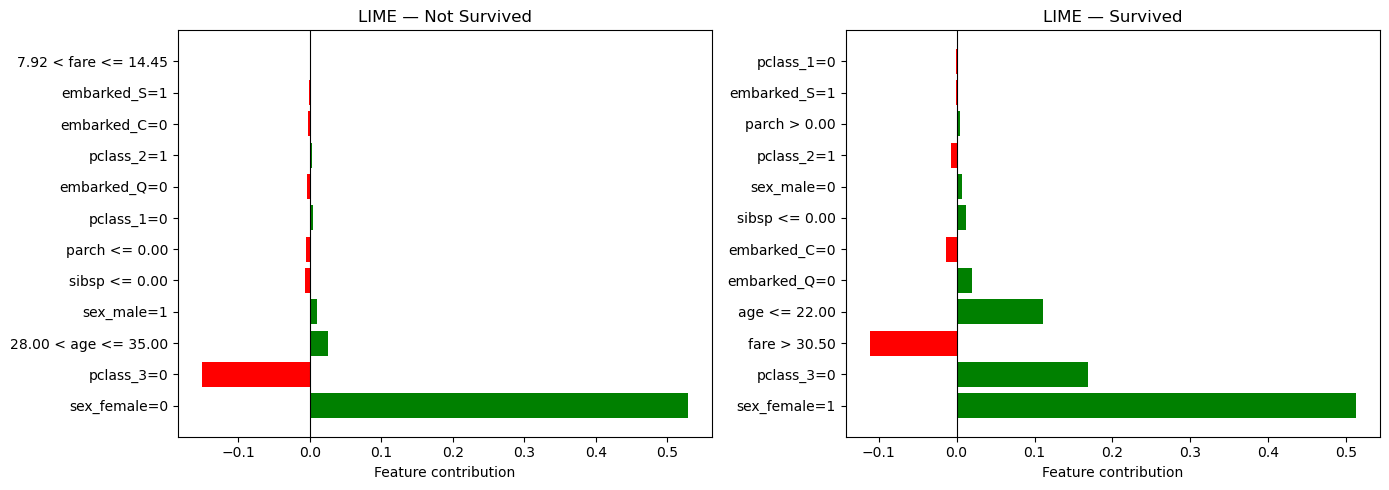

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, exp, label_idx, title in [
    (axes[0], exp_non, 0, "Not Survived"),
    (axes[1], exp_sur,  1, "Survived"),
]:
    vals = exp.as_list(label=label_idx)
    features, weights = zip(*vals)
    colors = ['green' if w > 0 else 'red' for w in weights]
    ax.barh(features, weights, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f"LIME — {title}")
    ax.set_xlabel("Feature contribution")

plt.tight_layout()
plt.savefig("lime_comparison.png", dpi=150)
plt.show()


In [45]:
# =========================
# FULL PIPELINE (robust on older sklearn)
# - preprocess (handles bool/bool nullable + categoricals)
# - train Keras NN
# - compute SHAP (KernelExplainer)
# - export high-quality figures (PDF + PNG)
# =========================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import shap

# -------------------------
# 0) Assumes you already have:
# X_train, X_test, y_train, y_test
# -------------------------

# -------------------------
# 1) Coerce boolean-like columns to numeric
# -------------------------
X_train_ = X_train.copy()
X_test_  = X_test.copy()

bool_like_cols = X_train_.select_dtypes(include=["bool", "boolean"]).columns.tolist()
if bool_like_cols:
    X_train_[bool_like_cols] = X_train_[bool_like_cols].astype("float64")
    X_test_[bool_like_cols]  = X_test_[bool_like_cols].astype("float64")

# -------------------------
# 2) Identify numeric vs categorical columns AFTER coercion
# -------------------------
num_cols = X_train_.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train_.select_dtypes(include=["object", "category"]).columns.tolist()

# -------------------------
# 3) Build preprocessing pipelines
# -------------------------
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse=False)),  # sklearn<=1.1
])

# IMPORTANT: only include transformers that actually have columns
transformers = []
if len(num_cols) > 0:
    transformers.append(("num", numeric_pipe, num_cols))
if len(cat_cols) > 0:
    transformers.append(("cat", categorical_pipe, cat_cols))

preprocess = ColumnTransformer(transformers=transformers, remainder="drop")

# -------------------------
# 4) Fit/transform preprocessing
# -------------------------
X_train_p = preprocess.fit_transform(X_train_)
X_test_p  = preprocess.transform(X_test_)

X_train_p = X_train_p.astype(np.float32)
X_test_p  = X_test_p.astype(np.float32)

# -------------------------
# 5) Robust feature names extraction (guards for empty categoricals)
# -------------------------
def get_feature_names_fitted(ct: ColumnTransformer, num_cols, cat_cols):
    # Newer sklearn: easiest
    if hasattr(ct, "get_feature_names_out"):
        return ct.get_feature_names_out().tolist()

    # Older sklearn: manual, but only if pieces exist
    names = []
    if len(num_cols) > 0:
        names.extend([str(c) for c in num_cols])

    if len(cat_cols) > 0:
        # Use fitted transformers_ (underscore!) which exists after fit
        # Find the fitted 'cat' transformer
        fitted_cat = None
        for name, trans, cols in ct.transformers_:
            if name == "cat":
                fitted_cat = trans
                break

        if fitted_cat is not None:
            # If pipeline, grab final OneHotEncoder
            ohe = fitted_cat.named_steps["onehot"] if hasattr(fitted_cat, "named_steps") else fitted_cat

            # Only call if actually fitted (has categories_)
            if hasattr(ohe, "categories_"):
                if hasattr(ohe, "get_feature_names_out"):
                    names.extend(ohe.get_feature_names_out(cat_cols).tolist())
                else:
                    names.extend(ohe.get_feature_names(cat_cols).tolist())

    return names

feature_names = get_feature_names_fitted(preprocess, num_cols, cat_cols)

# Sanity check
assert len(feature_names) == X_train_p.shape[1], (
    f"Feature name mismatch: {len(feature_names)} vs {X_train_p.shape[1]}"
)
print("Features:", len(feature_names))

# -------------------------
# 6) Train NN
# -------------------------
tf.random.set_seed(42)

model = keras.Sequential([
    layers.Input(shape=(X_train_p.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

history = model.fit(
    X_train_p, y_train.to_numpy(),
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)

print("Test metrics:", model.evaluate(X_test_p, y_test.to_numpy(), verbose=0))

# -------------------------
# 7) SHAP (KernelExplainer)
# -------------------------
rng = np.random.default_rng(42)

bg_size = min(100, X_train_p.shape[0])
bg_idx = rng.choice(X_train_p.shape[0], size=bg_size, replace=False)
X_bg = X_train_p[bg_idx]

explain_size = min(200, X_test_p.shape[0])
X_explain = X_test_p[:explain_size]

def predict_proba(X):
    return model.predict(X, verbose=0).reshape(-1)

explainer = shap.KernelExplainer(predict_proba, X_bg)
shap_values = explainer.shap_values(X_explain, nsamples=300)
shap_values = np.array(shap_values)

print("SHAP values shape:", shap_values.shape)

# -------------------------
# 8) Export high-quality plots
# -------------------------
# Beeswarm summary
plt.figure(figsize=(8, 6))
shap.summary_plot(
    shap_values,
    X_explain,
    feature_names=feature_names,
    max_display=20,
    show=False
)
plt.tight_layout()
plt.savefig("shap_summary.pdf", bbox_inches="tight")          # best for papers (vector)
plt.savefig("shap_summary.png", dpi=600, bbox_inches="tight") # best for slides/posters
plt.close()

# Bar summary
plt.figure(figsize=(6, 4))
shap.summary_plot(
    shap_values,
    X_explain,
    feature_names=feature_names,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.tight_layout()
plt.savefig("shap_bar.pdf", bbox_inches="tight")
plt.savefig("shap_bar.png", dpi=600, bbox_inches="tight")
plt.close()

print("Saved: shap_summary.pdf/png and shap_bar.pdf/png")


ModuleNotFoundError: No module named 'tensorflow'

### Diabetes database

In [ ]:
import pandas as pd

df = pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
target = 'Outcome'

In [ ]:
df = df.dropna(subset=['Outcome'])
df.shape

(768, 9)

In [ ]:
from sklearn.model_selection import train_test_split

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=5, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Feature columns:", list(X.columns))

Accuracy: 0.7922077922077922
Feature columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [ ]:
from sklearn.tree import export_graphviz
import graphviz

dot = export_graphviz(
    model,
    out_file=None,
    feature_names=X.columns,
    class_names=["No Diabetes", "Diabetes"],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot)
graph.render("diabetes_tree", format="png") 

'diabetes_tree.png'

### COMPAS Recidivism

In [20]:
import pandas as pd

url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw = pd.read_csv(url)

# ProPublica standard filtering
df = raw[
    (raw['days_b_screening_arrest'] <= 30) &
    (raw['days_b_screening_arrest'] >= -30) &
    (raw['is_recid'] != -1) &
    (raw['c_charge_degree'] != 'O') &
    (raw['score_text'] != 'N/A')
].copy()

# Feature engineering
df['race_black']      = (df['race'] == 'African-American').astype(int)
df['juv_any']         = ((df['juv_fel_count'] + df['juv_misd_count'] + df['juv_other_count']) > 0).astype(int)
df['sex']             = (df['sex'] == 'Male').astype(int)
df['c_charge_degree'] = (df['c_charge_degree'] == 'F').astype(int)

print(f"Rows after filtering: {len(df)}")
print(f"Recidivism rate: {df['two_year_recid'].mean():.1%}")
df[['age', 'sex', 'race_black', 'priors_count', 'c_charge_degree', 'juv_any', 'two_year_recid']].head()

Rows after filtering: 6172
Recidivism rate: 45.5%


,age,sex,race_black,priors_count,c_charge_degree,juv_any,two_year_recid
0,69,1,0,0,1,0,0
1,34,1,1,0,1,0,1
2,24,1,1,4,1,1,1
5,44,1,0,0,0,0,0
6,41,1,0,14,1,0,1


In [21]:
from sklearn.model_selection import train_test_split

features = ['age', 'sex', 'race_black', 'priors_count', 'c_charge_degree', 'juv_any']
target   = 'two_year_recid'

X = df[features].dropna()
y = df.loc[X.index, target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model_compas = DecisionTreeClassifier(max_depth=5, random_state=42)
model_compas.fit(X_train, y_train)

y_pred = model_compas.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Feature columns:", features)

Accuracy: 0.6623481781376518
Feature columns: ['age', 'sex', 'race_black', 'priors_count', 'c_charge_degree', 'juv_any']


In [23]:
import os
from sklearn.tree import export_graphviz
import graphviz

OUTPUT_DIR = "outputs_compas"
os.makedirs(OUTPUT_DIR, exist_ok=True)

dot = export_graphviz(
    model_compas,
    out_file=None,
    feature_names=features,
    class_names=["No Recidivism", "Recidivism"],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot)
graph.render(f"{OUTPUT_DIR}/compas_tree", format="png")
print(f"Saved: {OUTPUT_DIR}/compas_tree.png")

Saved: outputs_compas/compas_tree.png


#### COMPAS — Neural Network + SHAP

In [24]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=100,
    early_stopping=True,
    n_iter_no_change=10,
    validation_fraction=0.1,
    random_state=42
)
mlp.fit(X_train_s, y_train)

print(f"Neural Network train accuracy: {accuracy_score(y_train, mlp.predict(X_train_s)):.4f}")
print(f"Neural Network test  accuracy: {accuracy_score(y_test,  mlp.predict(X_test_s)):.4f}")
print()
print(classification_report(y_test, mlp.predict(X_test_s), target_names=["No Recidivism", "Recidivism"]))

Neural Network train accuracy: 0.6929
Neural Network test  accuracy: 0.6648

               precision    recall  f1-score   support

No Recidivism       0.67      0.76      0.72       683
   Recidivism       0.65      0.54      0.59       552

     accuracy                           0.66      1235
    macro avg       0.66      0.65      0.65      1235
 weighted avg       0.66      0.66      0.66      1235



In [25]:
import shap
import matplotlib.pyplot as plt
import numpy as np

predict_fn = lambda x: mlp.predict_proba(scaler.transform(x))

background = shap.sample(X_train, 50, random_state=42).values
X_explain  = X_test.iloc[:100].values

explainer = shap.KernelExplainer(predict_fn, background)
shap_vals = explainer.shap_values(X_explain, nsamples=200)

# SHAP >= 0.46 returns 3D (n_samples, n_features, n_classes); older returns list
if isinstance(shap_vals, list):
    sv = shap_vals[1]
else:
    sv = shap_vals[:, :, 1]

print(f"SHAP values shape: {sv.shape}")
print("Mean |SHAP| per feature:")
for feat, imp in sorted(zip(features, np.abs(sv).mean(axis=0)), key=lambda x: -x[1]):
    print(f"  {feat:25s} {imp:.4f}")

/Users/henrysalgado/opt/anaconda3/envs/data_science_env/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
  0%|          | 0/100 [00:00<?, ?it/s]/Users/henrysalgado/opt/anaconda3/envs/data_science_env/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/henrysalgado/opt/anaconda3/envs/data_science_env/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/henrysalgado/opt/anaconda3/envs/data_science_env/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/henrysalgado/opt/anaconda3/envs/data_science_env/lib/python3.10/si

SHAP values shape: (100, 6)
Mean |SHAP| per feature:
  priors_count              0.1512
  age                       0.0948
  c_charge_degree           0.0250
  sex                       0.0219
  race_black                0.0133
  juv_any                   0.0053


AssertionError: Feature and SHAP matrices must have the same number of rows!

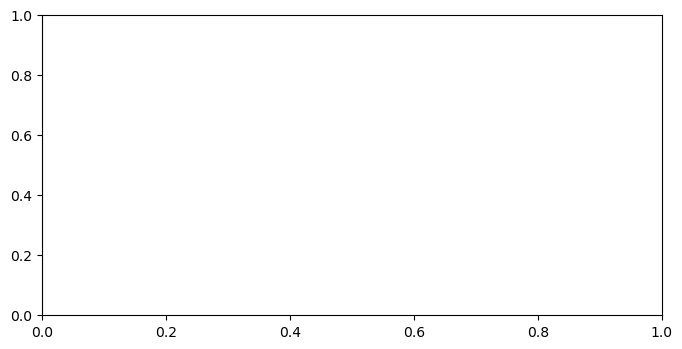

In [26]:
plt.figure(figsize=(8, 5))
shap.summary_plot(sv, X_test, feature_names=features, show=False)
plt.title("SHAP Summary (beeswarm) — COMPAS RF")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/compas_shap.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUTPUT_DIR}/compas_shap.png")

#### COMPAS — LIME Explanations

In [27]:
import lime
import lime.lime_tabular

cat_cols = ['sex', 'race_black', 'c_charge_degree', 'juv_any']
cat_feature_idx = [i for i, c in enumerate(features) if c in cat_cols]

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=features,
    class_names=['No Recidivism', 'Recidivism'],
    categorical_features=cat_feature_idx,
    mode='classification',
    random_state=42
)

# predict_fn scales before passing to MLP
lime_predict_fn = lambda x: mlp.predict_proba(scaler.transform(x))

In [28]:
import numpy as np

X_test_arr  = X_test.values
test_labels = y_test.reset_index(drop=True)

# Pick one recidivist and one non-recidivist from the test set
recid_idx     = test_labels[test_labels == 1].index[0]
no_recid_idx  = test_labels[test_labels == 0].index[0]

print(f"Recidivist instance (test index {recid_idx}):")
print(dict(zip(features, X_test_arr[recid_idx])))
print(f"\nNon-recidivist instance (test index {no_recid_idx}):")
print(dict(zip(features, X_test_arr[no_recid_idx])))

Recidivist instance (test index 0):
{'age': 26, 'sex': 1, 'race_black': 1, 'priors_count': 13, 'c_charge_degree': 0, 'juv_any': 0}

Non-recidivist instance (test index 1):
{'age': 31, 'sex': 1, 'race_black': 0, 'priors_count': 1, 'c_charge_degree': 0, 'juv_any': 1}


/Users/henrysalgado/opt/anaconda3/envs/data_science_env/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/henrysalgado/opt/anaconda3/envs/data_science_env/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


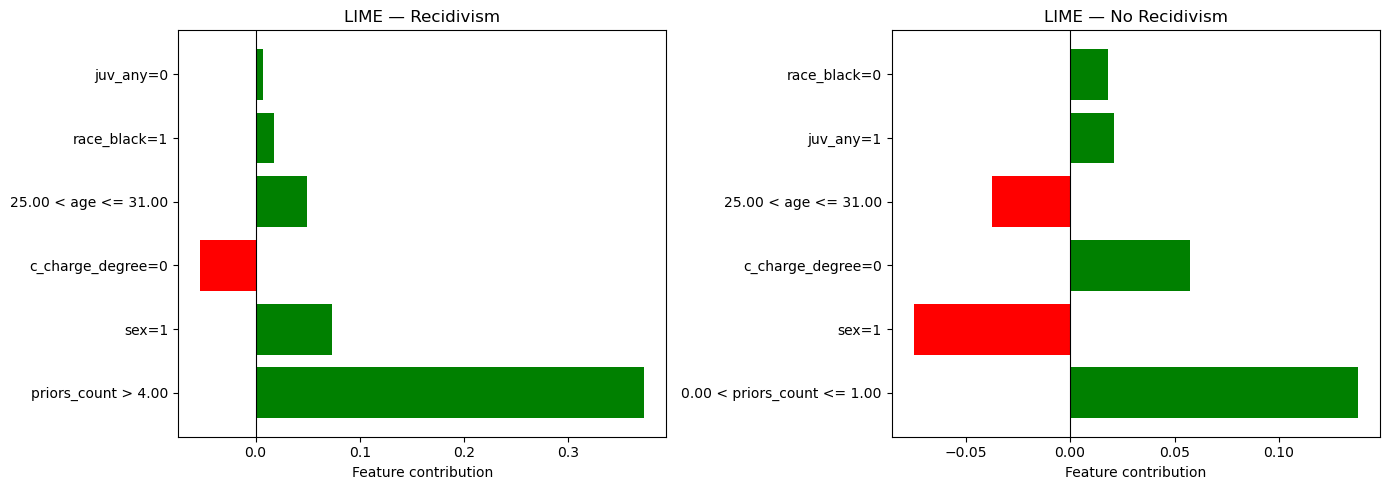

Saved: outputs_compas/compas_lime.png


In [29]:
import matplotlib.pyplot as plt

exp_recid = lime_explainer.explain_instance(
    X_test_arr[recid_idx],
    lime_predict_fn,
    num_features=len(features),
    labels=(0, 1)
)

exp_no_recid = lime_explainer.explain_instance(
    X_test_arr[no_recid_idx],
    lime_predict_fn,
    num_features=len(features),
    labels=(0, 1)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, exp, label_idx, title in [
    (axes[0], exp_recid,    1, "Recidivism"),
    (axes[1], exp_no_recid, 0, "No Recidivism"),
]:
    vals     = exp.as_list(label=label_idx)
    feats, weights = zip(*vals)
    colors   = ['green' if w > 0 else 'red' for w in weights]
    ax.barh(feats, weights, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f"LIME — {title}")
    ax.set_xlabel("Feature contribution")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/compas_lime.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUTPUT_DIR}/compas_lime.png")